<a href="https://colab.research.google.com/github/mentor-pranaya/Cricket-Player-Performance-Prediction/blob/himanethri/Week_3_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cricket Player Performance Prediction  
## Week 1: Data Loading and Exploratory Data Analysis (EDA)

### Objective:
To load, clean, and understand the IPL cricket dataset using basic statistics and visualizations.


In [ ]:
#import all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
os.listdir('/content')


['.config',
 'deliveries_updated_mens_ipl_upto_2024.csv',
 'bowling_features.csv',
 'batting_features.csv',
 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv('/content/deliveries_updated_mens_ipl_upto_2024.csv')


In [ ]:
df.head()


,matchId,inning,over_ball,over,ball,batting_team,bowling_team,batsman,non_striker,bowler,batsman_runs,extras,isWide,isNoBall,Byes,LegByes,Penalty,dismissal_kind,player_dismissed,date
0,335982,1,0.1,0,1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,2008-04-18
1,335982,1,0.2,0,2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18
2,335982,1,0.3,0,3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18
3,335982,1,0.4,0,4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18
4,335982,1,0.5,0,5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18


In [ ]:
df.shape

(260920, 20)

In [ ]:
df.columns


Index(['matchId', 'inning', 'over_ball', 'over', 'ball', 'batting_team',
       'bowling_team', 'batsman', 'non_striker', 'bowler', 'batsman_runs',
       'extras', 'isWide', 'isNoBall', 'Byes', 'LegByes', 'Penalty',
       'dismissal_kind', 'player_dismissed', 'date'],
      dtype='object')

In [ ]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   matchId           260920 non-null  int64  
 1   inning            260920 non-null  int64  
 2   over_ball         260920 non-null  float64
 3   over              260920 non-null  int64  
 4   ball              260920 non-null  int64  
 5   batting_team      260920 non-null  object 
 6   bowling_team      260920 non-null  object 
 7   batsman           260920 non-null  object 
 8   non_striker       260920 non-null  object 
 9   bowler            260920 non-null  object 
 10  batsman_runs      260920 non-null  int64  
 11  extras            260920 non-null  int64  
 12  isWide            8381 non-null    float64
 13  isNoBall          1093 non-null    float64
 14  Byes              673 non-null     float64
 15  LegByes           4001 non-null    float64
 16  Penalty           2 

In [ ]:
df.isnull().sum()


,0
matchId,0
inning,0
over_ball,0
over,0
ball,0
batting_team,0
bowling_team,0
batsman,0
non_striker,0
bowler,0


In [ ]:
fill_cols = ['isWide', 'isNoBall', 'Byes', 'LegByes', 'Penalty']

df[fill_cols] = df[fill_cols].fillna(0)


In [ ]:
df[fill_cols].isnull().sum()


,0
isWide,0
isNoBall,0
Byes,0
LegByes,0
Penalty,0


In [ ]:
top_batsmen = df.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)
top_batsmen


,batsman_runs
batsman,
V Kohli,8014
S Dhawan,6769
RG Sharma,6630
DA Warner,6567
SK Raina,5536
MS Dhoni,5243
AB de Villiers,5181
CH Gayle,4997
RV Uthappa,4954


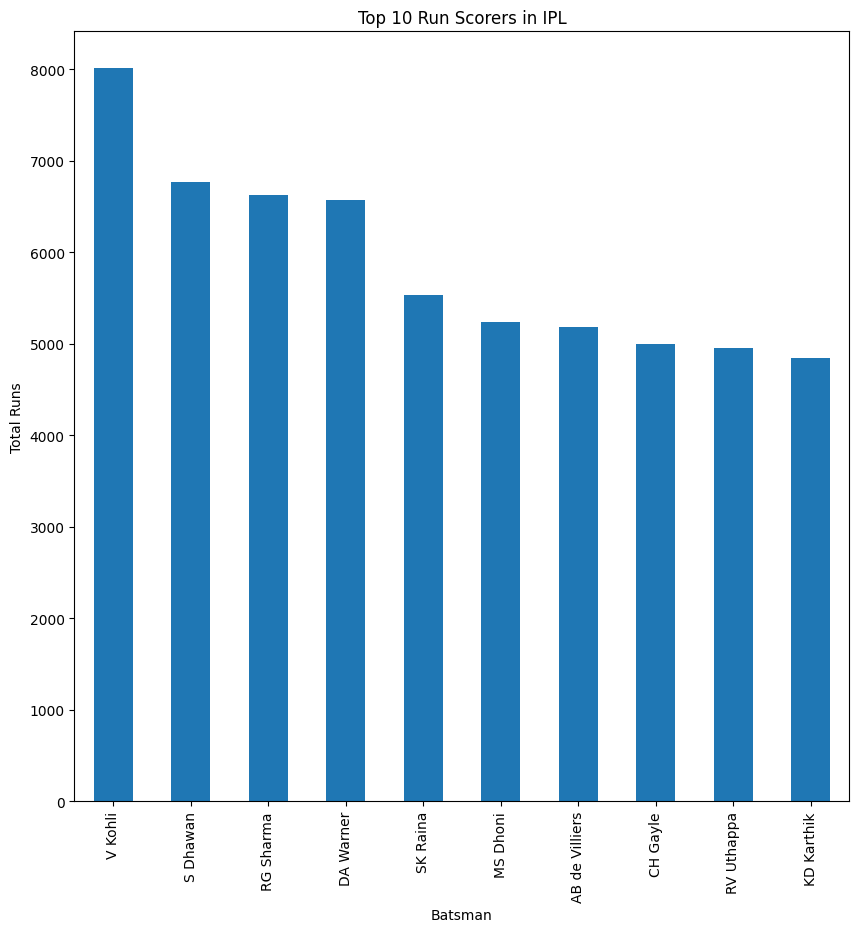

In [ ]:
import matplotlib.pyplot as plt

top_batsmen.plot(kind='bar', figsize=(10,10))
plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Batsman")
plt.ylabel("Total Runs")
plt.show()


#FEATURE ENGINEERING

In [ ]:
batting_df = df.groupby('batsman').agg(
    total_runs=('batsman_runs', 'sum'),
    balls_faced=('ball', 'count')
).reset_index()

batting_df.head()



,batsman,total_runs,balls_faced
0,A Ashish Reddy,280,196
1,A Badoni,634,505
2,A Chandila,4,7
3,A Chopra,53,75
4,A Choudhary,25,20


In [ ]:
batting_df['strike_rate'] = (
    batting_df['total_runs'] / batting_df['balls_faced']
) * 100


In [ ]:
bowling_df = df[df['dismissal_kind'].notna()]


In [ ]:
bowler_stats = bowling_df.groupby('bowler').agg(
    wickets=('dismissal_kind', 'count')
).reset_index()


In [ ]:
balls_df = df.groupby('bowler').agg(
    balls_bowled=('ball', 'count')
).reset_index()


In [ ]:
bowler_final = pd.merge(
    bowler_stats,
    balls_df,
    on='bowler',
    how='left'
)


In [ ]:
batting_df.to_csv('batting_features.csv', index=False)
bowler_final.to_csv('bowling_features.csv', index=False)


# WEEK -2
# FEATURE ENGINEERING

In [ ]:
batsman_df = df.groupby('batsman').agg(
    total_runs=('batsman_runs', 'sum'),
    balls_faced=('ball', 'count')).reset_index()

In [ ]:
batting_df.head()

,batsman,total_runs,balls_faced,strike_rate
0,A Ashish Reddy,280,196,142.857143
1,A Badoni,634,505,125.544554
2,A Chandila,4,7,57.142857
3,A Chopra,53,75,70.666667
4,A Choudhary,25,20,125.000000


In [ ]:
batting_df['strike_rate'] = (batting_df['total_runs']/batting_df['balls_faced'])*100

In [ ]:
batting_df.head()

,batsman,total_runs,balls_faced,strike_rate
0,A Ashish Reddy,280,196,142.857143
1,A Badoni,634,505,125.544554
2,A Chandila,4,7,57.142857
3,A Chopra,53,75,70.666667
4,A Choudhary,25,20,125.000000


In [ ]:
#extracting wicket details

wicket_df = df[df['dismissal_kind'].notna()]
wicket_df.head()

,matchId,inning,over_ball,over,ball,batting_team,bowling_team,batsman,non_striker,bowler,batsman_runs,extras,isWide,isNoBall,Byes,LegByes,Penalty,dismissal_kind,player_dismissed,date
33,335982,1,5.2,5,2,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,Z Khan,0,0,0.0,0.0,0.0,0.0,0.0,caught,SC Ganguly,2008-04-18
74,335982,1,12.1,12,1,Kolkata Knight Riders,Royal Challengers Bangalore,RT Ponting,BB McCullum,JH Kallis,0,0,0.0,0.0,0.0,0.0,0.0,caught,RT Ponting,2008-04-18
106,335982,1,17.1,17,1,Kolkata Knight Riders,Royal Challengers Bangalore,DJ Hussey,BB McCullum,AA Noffke,0,0,0.0,0.0,0.0,0.0,0.0,caught,DJ Hussey,2008-04-18
131,335982,2,1.1,1,1,Royal Challengers Bangalore,Kolkata Knight Riders,R Dravid,W Jaffer,I Sharma,0,0,0.0,0.0,0.0,0.0,0.0,bowled,R Dravid,2008-04-18
138,335982,2,2.2,2,2,Royal Challengers Bangalore,Kolkata Knight Riders,V Kohli,W Jaffer,AB Dinda,0,0,0.0,0.0,0.0,0.0,0.0,bowled,V Kohli,2008-04-18


In [ ]:
bowler_wickets = wicket_df.groupby('bowler').agg(
    wickets=('dismissal_kind', 'count')
).reset_index()
bowler_wickets.head()


,bowler,wickets
0,A Ashish Reddy,19
1,A Badoni,2
2,A Chandila,11
3,A Choudhary,5
4,A Flintoff,2


In [ ]:
bowler_balls = df.groupby('bowler').agg(
    balls_bowled=('ball', 'count')
).reset_index()
bowler_balls.head()

,bowler,balls_bowled
0,A Ashish Reddy,270
1,A Badoni,25
2,A Chandila,234
3,A Choudhary,108
4,A Dananjaya,25


In [ ]:
bowlig_df = pd.merge(
    bowler_wickets,
    bowler_balls,
    on='bowler',
    how='left'
)
bowling_df.head()


,matchId,inning,over_ball,over,ball,batting_team,bowling_team,batsman,non_striker,bowler,batsman_runs,extras,isWide,isNoBall,Byes,LegByes,Penalty,dismissal_kind,player_dismissed,date
33,335982,1,5.2,5,2,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,Z Khan,0,0,0.0,0.0,0.0,0.0,0.0,caught,SC Ganguly,2008-04-18
74,335982,1,12.1,12,1,Kolkata Knight Riders,Royal Challengers Bangalore,RT Ponting,BB McCullum,JH Kallis,0,0,0.0,0.0,0.0,0.0,0.0,caught,RT Ponting,2008-04-18
106,335982,1,17.1,17,1,Kolkata Knight Riders,Royal Challengers Bangalore,DJ Hussey,BB McCullum,AA Noffke,0,0,0.0,0.0,0.0,0.0,0.0,caught,DJ Hussey,2008-04-18
131,335982,2,1.1,1,1,Royal Challengers Bangalore,Kolkata Knight Riders,R Dravid,W Jaffer,I Sharma,0,0,0.0,0.0,0.0,0.0,0.0,bowled,R Dravid,2008-04-18
138,335982,2,2.2,2,2,Royal Challengers Bangalore,Kolkata Knight Riders,V Kohli,W Jaffer,AB Dinda,0,0,0.0,0.0,0.0,0.0,0.0,bowled,V Kohli,2008-04-18


In [ ]:
batting_df.to_csv('batting_features.csv', index=False)
bowling_df.to_csv('bowling_features.csv', index=False)


# Week 3: Model Training

Baseline Model – Linear Regression


In [ ]:
#Basline lienar regression model

In [ ]:
#import necessary module
#sci-kit library
#model_selection module for splitting data using train_test_split function
from sklearn.model_selection import train_test_split
#linear_model for model sleection..here we use Linear regression class(we also have trees, ensemble modules)
from sklearn.linear_model import LinearRegression
#and metic module to evaluate the model..using mean_absolute error, mean_squared error, r2_score functions
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
#now seperate the features and label

features = [
    'over',
    'ball',
    'isWide',
    'isNoBall',
    'extras',
    'Byes',
    'LegByes',
]

X = df[features]#obv input features
y = df['batsman_runs']#label

In [ ]:
#handle missig values
X = X.fillna(0)
y = y.fillna(0)

In [ ]:
#Now split the data into trianng and tesing data suing tain_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,#telling that my etst data size is 20% of entire data
    random_state = 42

)

In [ ]:
print(X_train.shape)
print(y_train.shape)


(208736, 7)
(208736,)


In [ ]:
#now train the model simply by creating the linear regression object and fitting the modle with th training data
lr_model = LinearRegression()#object created
lr_model.fit(X_train, y_train)#fit the model with the training data and let the model undertsand the patterns

LinearRegression()

In [ ]:
#now lets as the trained model to predics the Y values using the X_test testing data and later compare these reuslts with the actual y_test data
y_pred = lr_model.predict(X_test)

In [ ]:
print(y_pred)#my predicted data

[1.43452912 1.3310474  1.49498027 ... 1.44323941 1.43452912 1.13008237]


In [ ]:
#now lets chekc the errors int he model
#usw the funtions mean_absoule error for deviation from originl value
#mean_squared_error and rmse = mse(squared = false) for penalising big misarkes, smooth gradient -> helpful for optimixation(sensitive to outliers)
#r2_score to depit hw smart and explainable to mdoel is 1-SSres/SStotal(measures explained variance)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
R2 = r2_score(y_test, y_pred)

print("Linear Regression Model Performace:")
print("Mean Absolute Error: " , mae)
print("Mean Squared Error: " , mse)
print("Root Mean Squared Error: " , rmse)

print("R2: " , R2)

Linear Regression Model Performace:
Mean Absolute Error:  1.1854018081713757
Mean Squared Error:  2.6021545753252555
Root Mean Squared Error:  1.6131195167517054
R2:  0.027695783572349253


In [ ]:
print(type(r2_score))


<class 'function'>
